Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [2]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False

## doing the computations

In [10]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)

for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        
        for do_polar in [False, True]:

            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)
            
            print(50*'.')
            
            model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt'
            
            model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

            annotations = get_annotation('csv')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_complete_heat_map.parquet'
            print(df_filename)
            df_map = None
            
            with torch.no_grad():
                
                for i_image, (images, label) in tqdm(enumerate(image_datasets)):
                    
                    

                    image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                    
                    ground_true_indices, three_points, ground_true = get_ground_true(args, image_name, annotations, 'Imagenet')
                    
                    if ground_true.min() == 0.0:
                        
                        since = time.time()
                        
                        images = images.to(device, non_blocking=True)
                        
                        heat_map = model(images)
                        
                        _, pred_zero = torch.max(heat_map[pos_pred_zero].data, 0) # get the predicted label and its likelihood within the all image

                        pred_grid = torch.argmax(heat_map, dim=1) # get the most frequent predicted label (top1 and top5)
                        best_pred = torch.argmax(torch.bincount(pred_grid)).item()
                        best_pred_5 = label if label in get_top_indices(torch.bincount(pred_grid), 5) else best_pred
        
                        
        
                        sum = torch.argmax(torch.sum(heat_map, dim=0)).item() # get the label predict when we sum the evidence on all fixation points or inside the box
                        sum_in = torch.argmax(torch.sum(heat_map[ground_true_indices[0]], dim=0)).item()

                        

                        heatmap_soft = torch.nn.functional.softmax(model(images), dim=1)

                        likelihood_zero = torch.max(heatmap_soft[pos_pred_zero].data).item()
                        
                        heatmap_prior = heatmap_soft[:, label]
                        
                        mid_point, in_point, ext_point = get_like_point(heatmap_prior, args.resolution, three_points)

                        arg_max_prior = torch.argmax(heatmap_prior)
                        position_prior = (arg_max_prior.item()%args.resolution[0], arg_max_prior.item()//args.resolution[1])
                        pov_max_prior = heat_map[arg_max_prior]
                        _, pred_prior = torch.max(pov_max_prior.data, 0)
                        likelihood_prior = torch.max(heatmap_prior).item()
                    

                        arg_max_no_prior = torch.argmax(heatmap_soft)
                        pred_no_prior = (arg_max_no_prior%1000).item()
                        likelihood_no_prior = heatmap_soft[(arg_max_no_prior//1000),label].item()

                        

                        out_heat = th_delete(heatmap_prior, ground_true_indices[0])
                        

                        likelihood_out_max = torch.max(out_heat).item()
                        likelihood_in_max = torch.max(heatmap_prior[ground_true_indices[0]]).item()

                        likelihood_out_mean = torch.mean(out_heat).item()
                        likelihood_in_mean = torch.mean(heatmap_prior[ground_true_indices[0]]).item()

                        Iou = get_IoU(heatmap_prior.cpu(), ground_true.reshape(args.resolution[0]*args.resolution[1]))
                    
                        PG = 1 if likelihood_in_max > likelihood_out_max else 0
            
                        df_map_ = pd.DataFrame({'ImageId':image_name, 'likelihood_in_max': likelihood_in_max, 'likelihood_out_max': likelihood_out_max,
                                                                     'pred_zero':pred_zero.item(), 'pred_prior':pred_prior.item(), 'pred_no_prior':pred_no_prior, 'best_pred':best_pred, 
                                                                     'likelihood_prior':likelihood_prior, 'likelihood_zero':likelihood_zero, 'likelihood_no_prior':likelihood_no_prior, 'best_pred_5':best_pred_5, 
                                                                     'likelihood_out_mean': likelihood_out_mean, 'likelihood_in_mean': likelihood_in_mean,
                                                                     'mid_point':mid_point.item(), 'in_point':in_point.item(), 'ext_point':ext_point.item(), 'Iou': [Iou], 'position_prior':[position_prior],
                                                                     'sum':sum,'sum_in':sum_in, 'time':time.time() - since, 'label':label, 'PG':PG})
                        df_map = store_pandas(df_map, df_map_)
            
            df_map.to_parquet(df_filename)
                    
                        
            #imshow(images.cpu())
            #imshow(images[arg_max_prior].cpu())

model_data_set_type='full'
..................................................
args.do_polar=True
..................................................
loading .... cached_data/2024-05-24_full_resnet18_cartesian.pt
cached_data/2024-05-24_full_resnet18_cartesian_complete_heat_map.parquet


5it [00:01,  2.77it/s]


KeyboardInterrupt: 

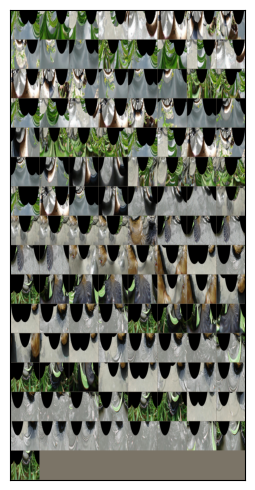

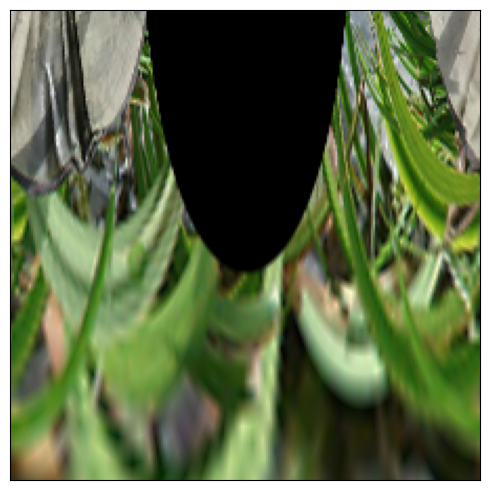

In [11]:
imshow(images.cpu())
imshow(images[arg_max_prior].cpu())

In [36]:
def get_pandas(model_data_set_type, model_name):
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_complete_heat_map.parquet'

    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df_ret = pd.read_parquet(df_filename)


    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_complete_heat_map.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
        
    return df, df_ret

df_filename='cached_data/2024-05-24_full_resnet18_retino_complete_heat_map.parquet'
df_filename='cached_data/2024-05-24_full_resnet18_cartesian_complete_heat_map.parquet'


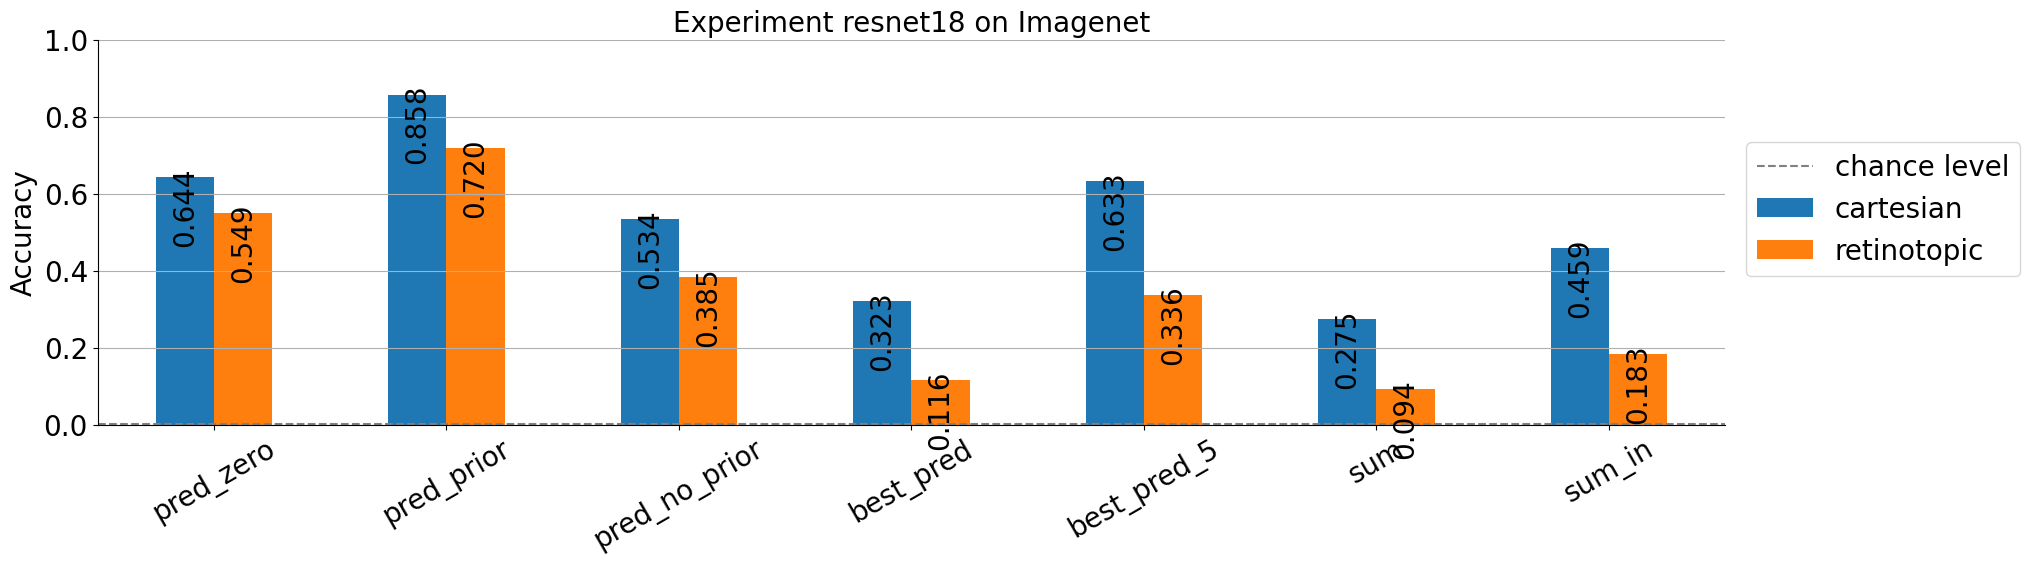

In [37]:
fig_width = 15
fontsize= 20
df, df_ret = get_pandas('full', 'resnet18')
        
df_acc_gray = pd.DataFrame({pred: {label: accuracy_score(df_[pred], df_["label"])
                                    for label, df_ in zip(['cartesian', 'retinotopic'], [df, df_ret])} 
                       for pred in ['pred_zero', 'pred_prior', 'pred_no_prior', 'best_pred', 'best_pred_5', 'sum', 'sum_in']})

ax = df_acc_gray.T.plot.bar(rot=30, figsize=(fig_width*1.4, fig_width//3), fontsize=fontsize)
ax.set_ylim(0, 1)
ax.hlines(xmin=-.5, xmax=7.5, y=1/1000, ls='--', ec='gray', label='chance level')
# https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_label_demo.html
for container in ax.containers: ax.bar_label(container, padding=-50, color='black', fontsize=fontsize, fmt='%.3f', rotation=90)
plt.legend(bbox_to_anchor=(1.19, .35), loc='lower right', fontsize=fontsize)
ax.grid(which='both', axis='y')
for side in ['top', 'right'] :ax.spines[side].set_visible(False)
ax.set_title(f'Experiment {model_name} on Imagenet', size=fontsize)
ax.set_ylabel('Accuracy', size=fontsize)
plt.show();

In [6]:
#for model_data_set_type in data_set_types: # data_set_types
for model_data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    
    print(50*'-')

    #for model_name in ['resnet18', 'resnet50', 'resnet101']:
    for model_name in ['resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [True, False]:
            
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')

            
            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_complete_heat_map.parquet'
            results = pd.read_parquet(df_filename)
            
            print(results['likelihood_in_mean'].mean(), 'likelihood_in_mean')
            print(results['likelihood_out_mean'].mean(), 'likelihood_out_mean')
            print(results['likelihood_out_mean'].mean()/results['likelihood_in_mean'].mean(), 'likelihood ratio')
            print(results['likelihood_in_max'].mean(), 'likelihood_in_max')
            print(results['likelihood_out_max'].mean(), 'likelihood_out_max')
            
            
            print(results['mid_point'].mean(), 'mid_point')
            print(results['in_point'].mean(), 'in_point')
            print(results['ext_point'].mean(), 'ext_point')
    
            mean_Iou = read_IoU(results['Iou'])
            print(mean_Iou[0], 'mean IoU')

            best_Iou = get_best_Iou(results['Iou'], np.argmax(mean_Iou[0]))
            
            for test_tresh in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
                inpel = 0
                for i, j in enumerate(results['likelihood_in_max']):
                    #print(i, j, results['max_in_heat'][i] , '>', results['max_out_heat'][i])
                    if best_Iou[i] > test_tresh and results['label'][i] == results['pred_prior'][i]:
                        inpel += 1
                print(inpel/len(results['likelihood_in_max']), f'GT-known : {test_tresh}')
        
            
            
            print(results['PG'].mean(), 'PG')
        


model_data_set_type='full'
--------------------------------------------------
model_name='resnet18'
..................................................
args.do_polar=True
..................................................
0.06892050496221086 likelihood_in_mean
0.017604858382750697 likelihood_out_mean
0.25543716477996564 likelihood ratio
0.5029624033863092 likelihood_in_max
0.1787356878753311 likelihood_out_max
0.10580953956948107 mid_point
0.041080855368152404 in_point
0.006074316510919043 ext_point
{0: 0.2866588748205218, 1: 0.08789639960507807, 2: 0.06256007219017917, 3: 0.04879349966439062, 4: 0.03945910375891286, 5: 0.031955312245596085, 6: 0.025744908647383543, 7: 0.01984781924933885, 8: 0.013490736331698745, 9: 0.0} mean IoU
0.7199018204131724 GT-known : 0
0.6465330333401513 GT-known : 0.1
0.5352219267743915 GT-known : 0.2
0.39298425035794643 GT-known : 0.3
0.18157087338924116 GT-known : 0.4
0.0 GT-known : 0.5
0.8192268357537329 PG
args.do_polar=False
.............................

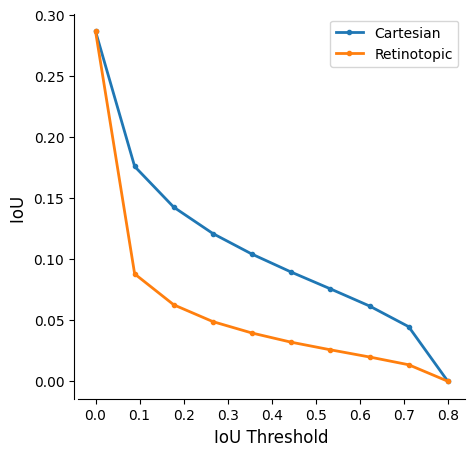

In [34]:
#subplotpars = matplotlib.figure.SubplotParams(left=0.1, right=.95, bottom=0.25, top=.975, hspace=.6)
dfs_ = {}

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plt.tick_params(axis='both', which='major', labelsize=10)
df, df_ret = get_pandas('full', 'resnet18')

for df_, label in zip([df, df_ret], [ 'Cartesian', 'Retinotopic']):

    mean_Iou, list_Iou = read_IoU(df_['Iou'])


    ax.plot(np.linspace(0,.8,10), list_Iou, lw=2, marker='.', label=label)
    ax.set_xlabel(f"IoU Threshold", size=12)
    ax.set_ylabel(f"IoU ", size=12)
    ax.spines['left'].set_position(('axes', -0.01))
    #ax.set_yscale("logit", one_half="1/2", use_overline=True)
    ax.grid(which='both')
    ax.legend()
    for side in ['top', 'right'] :ax.spines[side].set_visible(False)
    #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);

[0.8579873184700347, 0.7671098384127634, 0.6314788300265903, 0.46191450194313766, 0.21268152996522807, 0.0]
[0.7199018204131724, 0.6465330333401513, 0.5352219267743915, 0.39298425035794643, 0.18157087338924116, 0.0]


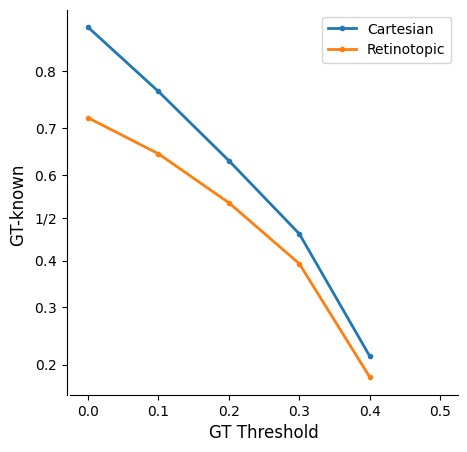

In [35]:
GT = {}
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plt.tick_params(axis='both', which='major', labelsize=10)
df, df_ret = get_pandas('full', 'resnet18')
for df_, label in zip([df, df_ret], ['Cartesian', 'Retinotopic']):
    GT[label] = []
    for test_tresh in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        inpel = 0
        for i, j in enumerate(df_['likelihood_in_max']):
            if best_Iou[i] > test_tresh and df_['label'][i] == df_['pred_prior'][i]:
                inpel += 1
        GT[label].append(inpel/len(df_['likelihood_in_max']))

    print(GT[label])
    ax.plot(np.asarray([0, 0.1, 0.2, 0.3, 0.4, 0.5]), GT[label], lw=2, marker='.', label=label)
    ax.set_xlabel(f"GT Threshold", size=12)
    ax.set_ylabel(f"GT-known ", size=12)
    ax.spines['left'].set_position(('axes', -0.01))
    ax.set_yscale("logit", one_half="1/2", use_overline=True)
    ax.grid(which='both')
    ax.legend()
    for side in ['top', 'right'] :ax.spines[side].set_visible(False)


/tmp/ipykernel_6654/1489688270.py:35: RuntimeWarning: Mean of empty slice.
  new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean())
/home/jnjer/.local/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


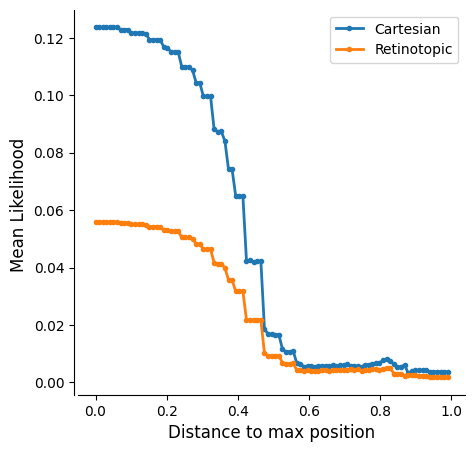

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def normalize_array(arr):
    # Convert the array to float type (if not already)
    arr = arr.astype(float)
    
    # Calculate the minimum and maximum values in the array
    min_val = np.min(arr)
    max_val = np.max(arr)
    
    # Normalize the array between 0 and 1
    normalized_arr = (arr - min_val) / (max_val - min_val)
    
    return normalized_arr
    
with open(f'cached_data/2024-04-06_likelihood_map_resnet101_False.csv', 'r') as csv_file:
       # results = pd.read_csv(csv_file, error_bad_lines=False)
             results = pd.read_csv(csv_file)
dist = get_dist(results['dist'])

distance_plot = np.concatenate(dist)
distance_plot = normalize_array(distance_plot)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plt.tick_params(axis='both', which='major', labelsize=10)
df, df_ret = get_pandas('full', 'resnet18')
for df_, label in zip([df, df_ret], ['Cartesian', 'Retinotopic']):
    list_dist = []
    

    likelihood_plot = np.concatenate([np.array(df_['in_point']), np.array(df_['mid_point']), np.array(df_['ext_point'])])
    
    new_likelihood_plot = []
    for i in np.linspace(0, 1, 100 ):
        new_likelihood_plot.append(likelihood_plot[np.where(distance_plot > i)].mean()) 



    ax.plot(np.linspace(0, 1, 100 ), new_likelihood_plot, lw=2, marker='.', label=label)
    ax.set_xlabel(f"Distance to max position", size=12)
    ax.set_ylabel(f"Mean Likelihood ", size=12)
    ax.spines['left'].set_position(('axes', -0.01))

    ax.grid(which='both')
    ax.legend()
    for side in ['top', 'right'] :ax.spines[side].set_visible(False)
    #axs[0].set_title(f'Average values of the accuracy for different parameters :', size=10);
            

